# Stage 09: Feature Engineering — Next-Day AAPL Volatility

This notebook converts the Stage 08 AAPL OHLCV dataset into leakage-aware features for predicting next trading day's absolute return.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.features import build_market_features

SOURCE_PATH = PROJECT_ROOT.parent / "stage8/data/raw/aapl_daily_ohlcv.csv"
RAW_PATH = PROJECT_ROOT / "data/raw/aapl_daily_ohlcv.csv"
PROCESSED_PATH = PROJECT_ROOT / "data/processed/aapl_feature_table.csv"
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
raw_df = pd.read_csv(SOURCE_PATH)
raw_df.to_csv(RAW_PATH, index=False)
sns.set_theme(style="whitegrid")
print("Raw shape:", raw_df.shape)

Matplotlib is building the font cache; this may take a moment.


Raw shape: (100, 6)


## Target and Leakage Rule

The target is `target_next_day_abs_return`: the absolute close-to-close return on trading day `t+1`. Every feature stored on row `t` uses information available no later than the end of day `t`. Initial rolling rows and the final target row remain missing and are dropped only when constructing the modeling table.

In [2]:
feature_df = build_market_features(raw_df, volatility_window=5)
numeric_features = [
    "return_lag_1", "absolute_return_lag_1", "rolling_volatility_5d",
    "volume_change_1d", "intraday_range_pct", "close_vs_5d_mean",
]
weekday_features = [column for column in feature_df.columns if column.startswith("weekday_")]
target = "target_next_day_abs_return"
modeling_df = feature_df.dropna(subset=numeric_features + [target]).copy()
print("Complete modeling rows:", len(modeling_df))
display(modeling_df[["date"] + numeric_features + weekday_features + [target]].head())

Complete modeling rows: 94


,date,return_lag_1,absolute_return_lag_1,rolling_volatility_5d,volume_change_1d,intraday_range_pct,close_vs_5d_mean,weekday_Monday,weekday_Tuesday,weekday_Wednesday,weekday_Thursday,weekday_Friday,target_next_day_abs_return
5,2026-04-07,-0.020706,0.020706,0.016114,1.118929,0.040991,-0.007983,0,1,0,0,0,0.021302
6,2026-04-08,0.021302,0.021302,0.014032,-0.339757,0.012459,0.009113,0,0,1,0,0,0.006141
7,2026-04-09,0.006141,0.006141,0.013990,-0.314656,0.019498,0.011478,0,0,0,1,0,0.000038
8,2026-04-10,-0.000038,0.000038,0.014043,0.112721,0.012181,0.007870,0,0,0,0,1,0.004914
9,2026-04-13,-0.004914,0.004914,0.013739,0.157974,0.013553,0.002654,1,0,0,0,0,0.001427


## Feature 1 — Recent Return and Absolute Return

**Implementation:** `return_lag_1` is today's signed close-to-close return, and `absolute_return_lag_1` is its magnitude. Both are one trading step behind the next-day target.

**Rationale from Stage 08:** Returns were left-skewed and heavy-tailed, and daily plots suggested changing volatility. The signed value can capture asymmetric reactions after down/up days; the absolute value tests short-run volatility clustering.

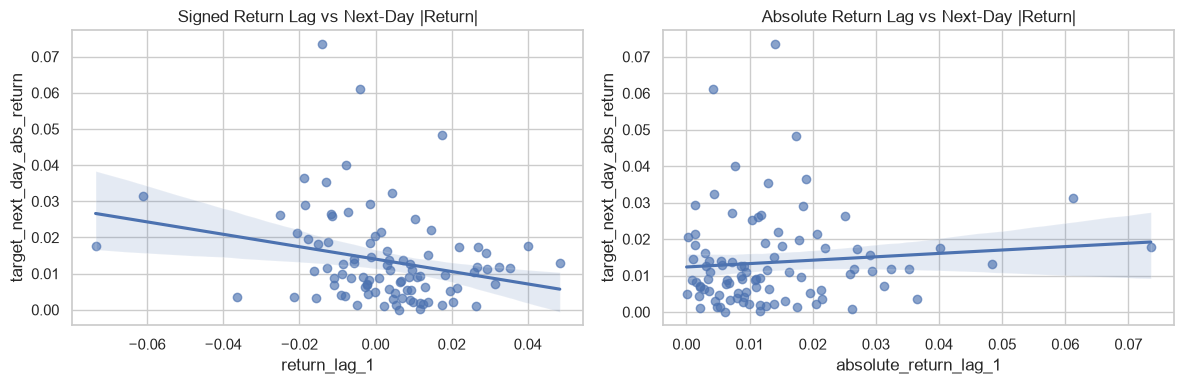

Correlation signed lag: -0.251
Correlation absolute lag: 0.093


In [3]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=modeling_df, x="return_lag_1", y=target, ax=axes[0], scatter_kws={"alpha": 0.65})
sns.regplot(data=modeling_df, x="absolute_return_lag_1", y=target, ax=axes[1], scatter_kws={"alpha": 0.65})
axes[0].set_title("Signed Return Lag vs Next-Day |Return|")
axes[1].set_title("Absolute Return Lag vs Next-Day |Return|")
figure.tight_layout()
plt.show()
print("Correlation signed lag:", round(modeling_df["return_lag_1"].corr(modeling_df[target]), 3))
print("Correlation absolute lag:", round(modeling_df["absolute_return_lag_1"].corr(modeling_df[target]), 3))

**Check:** The signed lag has a moderate negative correlation near -0.25, while absolute lag is weakly positive near 0.09. In this short sample, negative-return days tend to precede larger next-day moves more than magnitude alone does; this relationship needs time-ordered validation.

## Feature 2 — Five-Day Rolling Volatility and Price Position

**Implementation:** `rolling_volatility_5d` is the population standard deviation of the latest five daily returns. `close_vs_5d_mean` measures the current close relative to its five-day rolling mean.

**Rationale from Stage 08:** The time plot showed changing levels and volatility rather than stable seasonality. Rolling statistics summarize the local regime without using future observations.

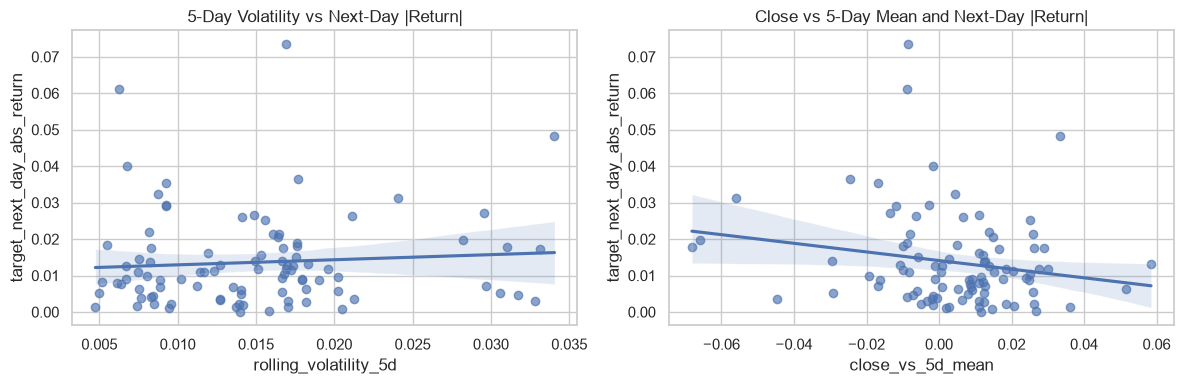

Correlation rolling volatility: 0.078
Correlation price position: -0.193


In [4]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=modeling_df, x="rolling_volatility_5d", y=target, ax=axes[0], scatter_kws={"alpha": 0.65})
sns.regplot(data=modeling_df, x="close_vs_5d_mean", y=target, ax=axes[1], scatter_kws={"alpha": 0.65})
axes[0].set_title("5-Day Volatility vs Next-Day |Return|")
axes[1].set_title("Close vs 5-Day Mean and Next-Day |Return|")
figure.tight_layout()
plt.show()
print("Correlation rolling volatility:", round(modeling_df["rolling_volatility_5d"].corr(modeling_df[target]), 3))
print("Correlation price position:", round(modeling_df["close_vs_5d_mean"].corr(modeling_df[target]), 3))

**Check:** Five-day volatility is only weakly related to the next-day target (about 0.08), while price position is modestly negative (about -0.19). The rolling features may become useful jointly or nonlinearly, but neither is a strong standalone predictor here.

## Feature 3 — Volume Change and Intraday Range

**Implementation:** `volume_change_1d` is the percentage change in trading volume; `intraday_range_pct` scales the high-low range by open price.

**Rationale from Stage 08:** Volume correlated about 0.50 with absolute same-day return and 0.52 with intraday range. These features test whether current activity and price dispersion carry forward into next-day volatility.

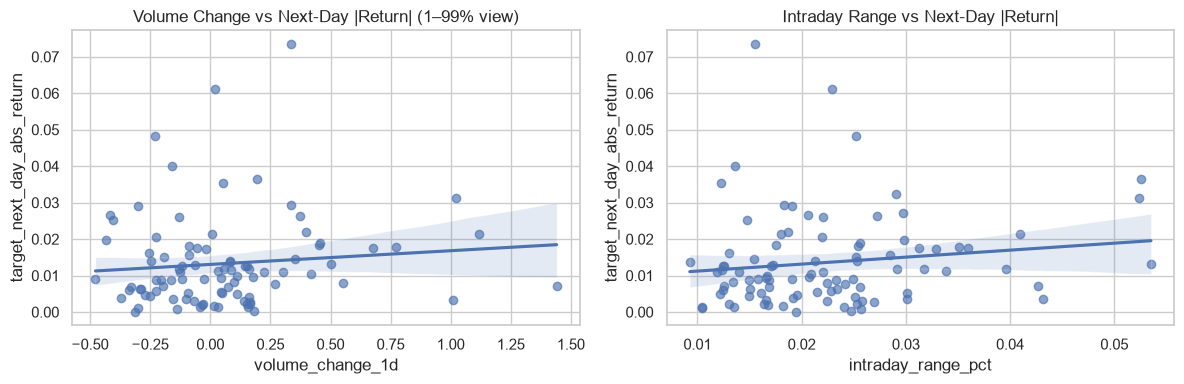

Correlation volume change (all rows): 0.141
Correlation intraday range: 0.141


In [5]:
volume_plot_df = modeling_df.loc[modeling_df["volume_change_1d"].between(
    modeling_df["volume_change_1d"].quantile(0.01), modeling_df["volume_change_1d"].quantile(0.99))]
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=volume_plot_df, x="volume_change_1d", y=target, ax=axes[0], scatter_kws={"alpha": 0.65})
sns.regplot(data=modeling_df, x="intraday_range_pct", y=target, ax=axes[1], scatter_kws={"alpha": 0.65})
axes[0].set_title("Volume Change vs Next-Day |Return| (1–99% view)")
axes[1].set_title("Intraday Range vs Next-Day |Return|")
figure.tight_layout()
plt.show()
print("Correlation volume change (all rows):", round(modeling_df["volume_change_1d"].corr(modeling_df[target]), 3))
print("Correlation intraday range:", round(modeling_df["intraday_range_pct"].corr(modeling_df[target]), 3))

**Check:** Both features have weak positive correlations near 0.14. Stage 08's strong same-day relationship does not fully carry into the next day, which is an important distinction between descriptive association and predictive usefulness.

## Feature 4 — Weekday One-Hot Encoding

**Implementation:** `weekday` is derived from the trading date and encoded into deterministic Monday–Friday binary columns.

**Rationale from Stage 08:** The EDA profiled observations by weekday but did not establish seasonality. One-hot encoding allows a later model to test day-specific effects without imposing an artificial numeric order.

,mean,median,count
weekday,,,
Monday,0.014391,0.010190,18
Tuesday,0.013568,0.010983,20
Wednesday,0.012944,0.009048,20
Thursday,0.015897,0.012499,19
Friday,0.011103,0.011681,17


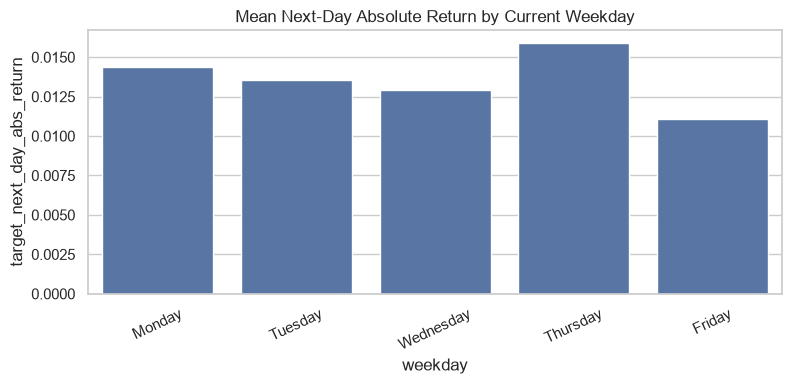

,correlation_with_target
weekday_Friday,-0.093721
weekday_Wednesday,-0.027804
weekday_Tuesday,-0.002049
weekday_Monday,0.029853
weekday_Thursday,0.091000


In [6]:
weekday_summary = modeling_df.groupby("weekday", observed=True)[target].agg(["mean", "median", "count"])
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekday_summary = weekday_summary.reindex(weekday_order)
display(weekday_summary)
figure, axis = plt.subplots(figsize=(8, 4))
sns.barplot(data=modeling_df, x="weekday", y=target, order=weekday_order, errorbar=None, ax=axis)
axis.set_title("Mean Next-Day Absolute Return by Current Weekday")
axis.tick_params(axis="x", rotation=25)
figure.tight_layout()
plt.show()
weekday_correlations = modeling_df[weekday_features + [target]].corr()[target].drop(target).sort_values()
display(weekday_correlations.rename("correlation_with_target").to_frame())

**Check:** Thursday has the highest sample mean, but every weekday one-hot correlation has absolute magnitude below 0.10. The encoded feature is reproducible and model-ready, yet there is no strong calendar signal in only 94 complete rows.

## Combined Feature–Target Correlation Check

,correlation_with_target
return_lag_1,-0.251154
close_vs_5d_mean,-0.193390
intraday_range_pct,0.141128
volume_change_1d,0.140688
weekday_Friday,-0.093721
absolute_return_lag_1,0.093269
weekday_Thursday,0.091000
rolling_volatility_5d,0.077616
weekday_Monday,0.029853
weekday_Wednesday,-0.027804


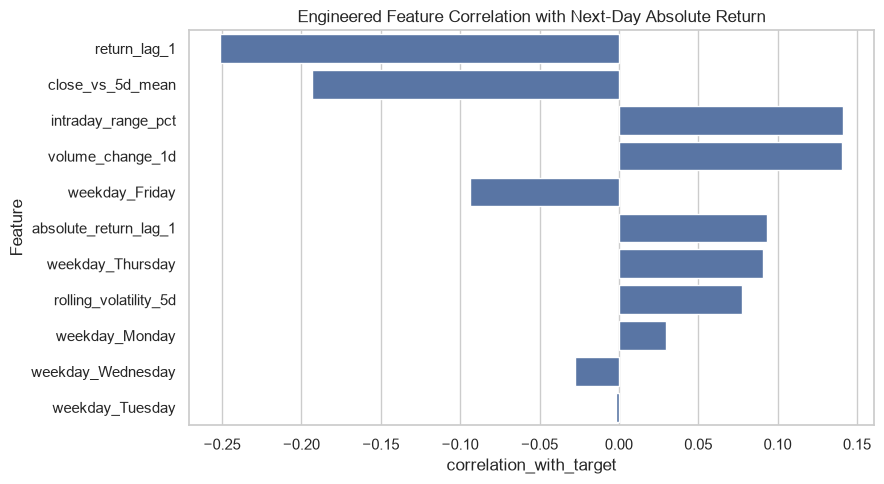

In [7]:
correlation_table = (
    modeling_df[numeric_features + weekday_features + [target]]
    .corr()[target].drop(target).sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("correlation_with_target").to_frame()
)
display(correlation_table)
figure, axis = plt.subplots(figsize=(9, 5))
sns.barplot(data=correlation_table.reset_index(), x="correlation_with_target", y="index", ax=axis)
axis.set(title="Engineered Feature Correlation with Next-Day Absolute Return", ylabel="Feature")
figure.tight_layout()
plt.show()

## Save and Validate the Feature Table

In [8]:
output_columns = ["date"] + numeric_features + ["weekday"] + weekday_features + [target]
modeling_df[output_columns].to_csv(PROCESSED_PATH, index=False)
saved_df = pd.read_csv(PROCESSED_PATH, parse_dates=["date"])
assert saved_df.shape == (94, len(output_columns))
assert saved_df[numeric_features + weekday_features + [target]].isna().sum().sum() == 0
assert saved_df[weekday_features].sum(axis=1).eq(1).all()
assert saved_df["date"].is_monotonic_increasing
print("Feature table validation passed: True")
print("Saved:", PROCESSED_PATH.relative_to(PROJECT_ROOT))

Feature table validation passed: True
Saved: data/processed/aapl_feature_table.csv


## Conclusions and Modeling Implications

The strongest single linear relationship is the signed current-day return, followed by price position, intraday range, and volume change. None is strong enough to justify a predictive claim on its own, and weekday effects are especially weak. Stage 10b should compare these features against a rolling-volatility baseline using time-ordered or walk-forward validation. Feature scaling must be fitted only on training windows, and target alignment should be unit-tested because a one-row shift error would create severe leakage. Nonlinear models or interactions may capture structure missed by these marginal correlations, but the 94-row sample favors simple regularized models and restrained claims.